In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
#import cooler
import random
import pybedtools

In [793]:
eqtl=pd.read_csv('.../result_analysis/merged-withqval-fix.txt',sep='\t')

eqtl.Gene=eqtl.Gene.str.split('.',expand=True)[0]

In [885]:
glm=pd.read_csv('.../result_sign_of_poisson_glm_100k_strict_qval_0.1.txt',sep='\t')

In [886]:
glm.drop_duplicates('lab_dist',keep=False,inplace=True)

In [887]:
glm=glm.loc[glm.dist!=0]

In [888]:
glm=glm[['dist','snp','lab_dist']]

In [889]:
glm['snp_start']=(glm.snp.str.split(':',expand=True)[1]).astype(int)
glm['chr']=glm.snp.str.split(':',expand=True)[0]


In [890]:
glm=glm[['chr','snp_start','dist','lab_dist']]
glm.columns=['chrom','snp_start','id','lab_dist']

In [891]:
res_df=glm

In [892]:
res_df['id']=res_df['id'].astype(int)

In [893]:
res_df['inter_bin']=res_df.snp_start.astype(int)+100000*res_df['id'].astype(int)
res_df['inter_bin_end']=res_df['inter_bin']+100000


In [894]:
res_df.reset_index(drop=True,inplace=True)

In [895]:
len(res_df)

103

In [896]:
genes=pd.read_csv('.../genes_hg38_ens_ids.txt',sep='\t',header=None)
genes_bed=pybedtools.BedTool.from_dataframe(genes[[0,1,2,3]])

res_df['index']=res_df.index
inter_bin_bed=pybedtools.BedTool.from_dataframe(res_df[['chrom','inter_bin','inter_bin_end','index']])

tmp1=inter_bin_bed.intersect(genes_bed,wao=True).to_dataframe()
snp_bed=pybedtools.BedTool.from_dataframe(res_df[['chrom','snp_start','snp_start','index']])

tmp2=snp_bed.intersect(genes_bed,wao=True).to_dataframe()

tmp1=tmp1[['chrom','start','thickEnd','name']]
tmp1.columns=['chrom','bin_start','gene','id']
tmp2=tmp2[['end','thickEnd','name']]
tmp2.columns=['snp_pos','snp_gene','id']


tmp2.index=tmp2['id']
data=tmp1.join(tmp2,  on='id', lsuffix='_ib',rsuffix='_snp')

In [897]:
l1=len(data.loc[(data.gene==data.snp_gene)&(data.gene!='.')].drop_duplicates('id_snp'))


In [898]:
l2=len(data.loc[(data.gene=='.')&(data.snp_gene=='.')].drop_duplicates('id_snp'))


In [899]:
l3=len(data.loc[(data.gene!='.')&(data.snp_gene=='.')].drop_duplicates('id_snp'))


In [900]:
l4=len(data.loc[(data.gene=='.')&(data.snp_gene!='.')].drop_duplicates('id_snp'))

In [901]:
same_gene=data.loc[(data.gene==data.snp_gene)]
l5=len(data.loc[(~data.id_snp.isin(same_gene.id_ib)&(data.gene!='.')&(data.snp_gene!='.'))].drop_duplicates('id_snp'))

In [902]:
res_df['lab']=res_df.chrom+':'+res_df.snp_start.astype(str)

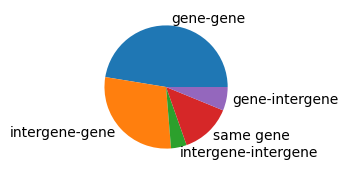

In [903]:
labels = ['gene-gene', 'intergene-gene', 'intergene-intergene', 'same gene','gene-intergene']
sizes = [int(l5/len(res_df)*100), int(l3/len(res_df)*100), int(l2/len(res_df)*100), int(l1/len(res_df)*100),int(l4/len(res_df)*100)]


fig, ax = plt.subplots(figsize=(2,2))

ax.pie(sizes, labels=labels)


In [904]:
control_glm=pd.read_csv('.../no_sign_result_of_poisson_glm_100k_strict_qval_0.1.txt',sep='\t')

In [905]:
control_glm=control_glm[['dist','snp']]


In [906]:
control_glm.columns=['id','lab']

In [907]:
control=control_glm

In [908]:
control['id']=control['id'].astype(float)

In [909]:
control.drop_duplicates(inplace=True)

In [910]:
control['lab_dist']=control.lab+':'+control['id'].astype(str)

In [911]:
control=control.loc[~control.lab_dist.isin(res_df.lab_dist)]

In [912]:
control.reset_index(drop=True,inplace=True)

In [913]:
control['snp_start']=(control.lab.str.split(':',expand=True)[1]).astype(int)
control['chr']=control.lab.str.split(':',expand=True)[0]
control=control[['chr','snp_start','id','lab_dist']]
control.columns=['chrom','snp_start','id','lab_dist']

In [914]:
control['inter_bin']=control.snp_start.astype(int)+100000*control['id'].astype(int)
control['inter_bin_end']=control['inter_bin']+100000


In [915]:
control['index']=control.index
inter_bin_bed=pybedtools.BedTool.from_dataframe(control[['chrom','inter_bin','inter_bin_end','index']])

tmp1=inter_bin_bed.intersect(genes_bed,wao=True).to_dataframe()
snp_bed=pybedtools.BedTool.from_dataframe(control[['chrom','snp_start','snp_start','index']])

tmp2=snp_bed.intersect(genes_bed,wao=True).to_dataframe()

tmp1=tmp1[['chrom','start','thickEnd','name']]
tmp1.columns=['chrom','bin_start','gene','id']
tmp2=tmp2[['end','thickEnd','name']]
tmp2.columns=['snp_pos','snp_gene','id']


tmp2.index=tmp2['id']
data_control=tmp1.join(tmp2,  on='id', lsuffix='_ib',rsuffix='_snp')

In [916]:
same_gene=data.loc[(data.gene==data.snp_gene)]
data1=data.loc[(data.gene!='.')&(data.snp_gene=='.')]

In [917]:
same_gene=data_control.loc[(data_control.gene==data_control.snp_gene)]
data_control1=data_control.loc[(data_control.gene!='.')&(data_control.snp_gene=='.')]

In [918]:
eqtl
dt=[]
for i in range(len(data1)):
    t_gene=data1.iloc[i]['gene']
    t_eqtl=eqtl.loc[eqtl.Gene==t_gene]
    if len(t_eqtl)>0:
        min_dist=min(abs(t_eqtl.SNPPos-data1.iloc[i]['snp_pos']))
        dt.append(min_dist)
        
    else:
        dt.append(np.nan)

In [919]:
dt=np.array(dt)

In [920]:
len(dt[np.isnan(dt)])

57

In [921]:
len(dt[~np.isnan(dt)])

37

In [922]:
dt_res=dt[~np.isnan(dt)]

In [923]:
data_control1['dist']=data_control1.snp_pos-data_control1.bin_start
data1['dist']=data1.snp_pos-data1.bin_start
data1_uniq=data1.drop_duplicates(['id'])
data_control1_uniq=data_control1.drop_duplicates(['id'])

In [924]:
data1['dist_to_eqtl']=dt

In [925]:
min_dist_res=data1[['id','dist_to_eqtl']].groupby('id').min().reset_index()

In [926]:
stat=[]
for j in range(1000):
    random_control=pd.DataFrame()
    for n in np.unique(data1_uniq.dist):
        t1=data_control1_uniq.loc[data_control1_uniq.dist==n]
        l=len(data1_uniq.loc[data1_uniq.dist==n])
        ids_tmp=np.random.choice(t1.index,l,replace=False)
        random_control=pd.concat([random_control,t1.loc[ids_tmp]])
    
    dt=[]
    random_control=data_control1.loc[data_control1['id'].isin(random_control['id'])]
    for i in range(len(random_control)):
        t_gene=random_control.iloc[i]['gene']
        t_eqtl=eqtl.loc[eqtl.Gene==t_gene]
        if len(t_eqtl)>0:
            min_dist=min(abs(t_eqtl.SNPPos-random_control.iloc[i]['snp_pos']))
            dt.append(min_dist)
        
        else:
            dt.append(np.nan)
    dt=np.array(dt)
    random_control['dist_to_eqtl']=dt
    min_dist_res_control=random_control[['id','dist_to_eqtl']].groupby('id').min().reset_index()
    #dt=dt[~np.isnan(dt)]
    control_dt=np.nanmean(min_dist_res_control.dist_to_eqtl)
    stat.append(control_dt)

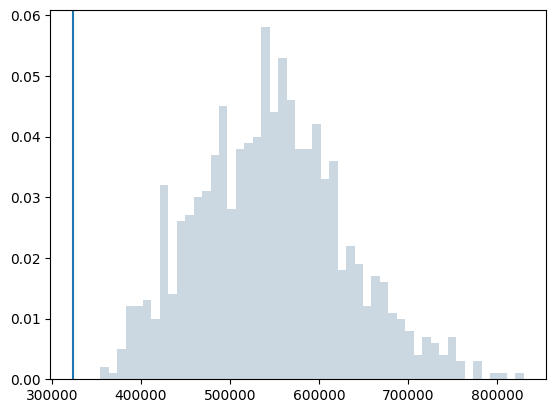

In [927]:
plt.hist(stat,bins=50,weights=np.zeros_like(stat) + 1. / np.array(stat).size,color=(205./256,217./256,226./256))
plt.axvline(np.nanmean(min_dist_res.dist_to_eqtl))


In [928]:
sum(np.nanmean(min_dist_res.dist_to_eqtl)>stat)/1000

np.float64(0.0)

In [929]:
##############

In [930]:
xx1=data.loc[data.gene!='.'][['chrom','bin_start','gene','snp_pos','id']].drop_duplicates()
expr=pd.read_csv('.../abundance_BA9_rizzardi_plus_salmon.txt')
expr['mean']=np.nanmean(expr,axis=1)
expr=expr[['mean']]
expr.columns=[1]
xx2=xx1.loc[xx1.gene.isin(expr.index)]
xx2['expr']=list(expr.loc[xx2.gene,1])

In [931]:
ag_inter=xx2.drop_duplicates('gene')

In [932]:
xx1=data_control.loc[data_control.gene!='.'][['chrom','bin_start','gene','snp_pos','id']].drop_duplicates()

xx2=xx1.loc[xx1.gene.isin(expr.index)]
xx2['expr']=list(expr.loc[xx2.gene,1])

In [933]:
ag_control=xx2.drop_duplicates('gene')

In [934]:
ag_control=ag_control.loc[~ag_control.gene.isin(ag_inter.gene)]

/home/akononkova/miniforge3/envs/biotools/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


MannwhitneyuResult(statistic=np.float64(62607.5), pvalue=np.float64(0.00012248053750113253))

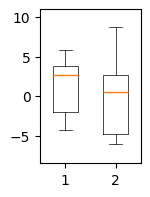

In [935]:
plt.figure(figsize=(1.3,2))
plt.boxplot([np.log(ag_inter.expr),np.log(ag_control.expr)],widths=0.5,boxprops={'linewidth':0.5},
            flierprops={'markersize':0.5},whiskerprops={'linewidth':0.5},capprops={'linewidth':0.5})
plt.ylim(-8.5,11)

scipy.stats.mannwhitneyu(ag_control.expr,ag_inter.expr)

In [936]:
d1=data[['chrom','bin_start','snp_pos','gene','snp_gene']].groupby(['chrom','bin_start','snp_pos'])['gene'].apply(list).reset_index()

In [937]:
d2=data[['chrom','bin_start','snp_pos','gene','snp_gene']].groupby(['chrom','bin_start','snp_pos'])['snp_gene'].apply(list).reset_index()

In [938]:
d1['snp_gene']=d2.snp_gene

In [939]:
s1=[]
s2=[]
for i in range(len(d1)):
    x1=d1.iloc[i]['gene']
    x1=np.unique(x1)
    s1.append(x1)
    x2=d1.iloc[i]['snp_gene']
    x2=np.unique(x2)
    s2.append(x2)

In [940]:
d1['gene']=s1
d1['snp_gene']=s2

In [941]:
d1.to_csv('.../table_SNP_poisson_int_with_genes_strict_qval_0.1.txt',index=None,sep='\t')

In [942]:
genes_in_cont=data.loc[(data.gene==data.snp_gene)&(data.gene!='.')][['gene']].drop_duplicates()

In [943]:
l_sg=genes.loc[genes[3].isin(genes_in_cont.gene)]

In [944]:
min(l_sg[2]-l_sg[1])

201762

In [945]:
l_sg[2]-l_sg[1]

2426      917258
11419     727179
33638     340964
33814     201762
38801    1287656
41350     847119
dtype: int64

In [946]:
gg=genes[2]-genes[1]

In [947]:
np.percentile(gg,q=np.arange(0,101,10))

array([8.000000e+00, 1.340000e+02, 4.120000e+02, 7.920000e+02,
       1.527000e+03, 3.580000e+03, 8.398000e+03, 1.764380e+04,
       3.637700e+04, 8.355930e+04, 2.473539e+06])

In [948]:
np.mean(l_sg[2]-l_sg[1])

np.float64(720323.0)

In [251]:
############### average maps ##################

In [252]:
def norm(ff,ch):
    s=ff.matrix(balance=True).fetch(ch)
    D=np.zeros(len(s))
    for i in range (len(s)):
        D[i]=np.nanmean(s.diagonal(i))
     
    A=np.zeros((len(s),len(s)))
    n=len(s)
    for i in range (len(s)):
        row_id=np.arange(0,(n-i))
        col_id=np.arange(i,n)

        if D[i]!=0:
            A[row_id,col_id]=s[row_id,col_id]/D[i]
            A[col_id,row_id]=s[col_id,row_id]/D[i]

    return(A)


In [949]:
a=res_df.copy()

In [950]:
a.to_csv('.../res_poisson_strict_qval_0.1.txt',sep='\t',index=None)

In [ ]:
names=['PFC_HC2M', 'PFC_HC3M', 'PFC_HC24', 'PFC_HC91', 'PFC_HC318', 'PFC_SZ1',
       'PFC_SZ3', 'PFC_SZ6', 'PFC_SZ8', 'PFC_SZ10','PFC_SZ20']
coolers={'PFC_HC2M':'HC-2Mplus.hg38.mapq_30.1000_20K.mcool', 'PFC_HC3M':'HC-3Mplus.hg38.mapq_30.1000_20K.mcool', 
         'PFC_HC24':'HC24plus.hg38.mapq_30.1000.20K.mcool', 'PFC_HC91':'HC-91plus.hg38.mapq_30.1000.mcool',
         'PFC_HC318':'HC-318plus.hg38.mapq_30.1000.mcool', 'PFC_SZ1':'SZ-01plus.hg38.mapq_30.1000_20K.mcool',
       'PFC_SZ3':'SZ-03plus.hg38.mapq_30.1000_20K.mcool', 
         'PFC_SZ6':'SZ6plus.hg38.mapq_30.20K.mcool', 'PFC_SZ8':'SZ08plus.hg38.mapq_30.1000.20K.mcool',
         'PFC_SZ10':'SZ10plus.hg38.mapq_30.20K.mcool', 'PFC_SZ20':'SZ-20plus.hg38.mapq_30.20K.mcool'}

images={}
central_enrichment={}

poly=a.copy()
poly['start1']=(poly.snp_start/20000).astype(int)
poly['start2']=(poly.inter_bin/20000).astype(int)

for n in names:
    c=cooler.Cooler('.../%s::resolutions/20000'%coolers[n])
    l=0
    scores=np.zeros((11,11,len(poly)))
    scores[:]=np.nan
    central_score=np.zeros(len(poly))
    central_score[:]=np.nan
    
    for ch in np.unique(poly['chrom']):
        tmp=poly.loc[poly['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            mm=m[x-5:x+6,y-5:y+6]
            
            back=mm.copy()
            back[4:7,4:7]=np.nan
            mm_enr=np.nanmean(mm[5:6,5:6])/np.nanmean(back)
            
            if (np.shape(mm)[0]!=11)|(np.shape(mm)[1]!=11):
                tt=np.zeros((11,11))
                tt[:]=np.nan
                scores[:,:,l]=tt
                central_score[l]=np.nan
            else:           
                scores[:,:,l]=mm
                central_score[l]=mm_enr

            l+=1
        
            
    images[n]=scores
    central_enrichment[n]=central_score

In [ ]:
snp=pd.read_csv('.../snp_from_freebayes_depth_more30.txt.gz')

snp['hg38']=snp['#CHROM']+':'+snp.POS.astype(str)

genot=snp.loc[snp.hg38.isin(a.lab)]


In [ ]:
x=np.zeros((11,11))
x[:]=np.nan
enrich={0:x,1:x,2:x}

z=np.zeros(1)
z[:]=np.nan
enrich_central={0:z,1:z,2:z}
memory_g=[]
memory_n=[]
for i in range(len(a)):
    snp=a.iloc[i]['lab']
    g=genot.loc[genot.hg38==snp][['PFC_HC2M', 'PFC_HC3M', 'PFC_HC24', 'PFC_HC91', 'PFC_HC318', 'PFC_SZ1',
       'PFC_SZ3', 'PFC_SZ5', 'PFC_SZ6', 'PFC_SZ8', 'PFC_SZ10']]
    
    g0=np.array(names)[g.iloc[0]=='0/0']
    g1=np.array(names)[g.iloc[0]=='0/1']
    g2=np.array(names)[g.iloc[0]=='1/1']
    k=0
    memory_g.append([len(g0),len(g1),len(g2)])
    memory_n.append([g0,g1,g2])
    for h in [g0,g1,g2]:
        
        y=np.zeros((11,11))
        y[:]=np.nan
        v=[np.nan]
    
        if len(h)>1:
            for j in h:
                y=np.dstack((y,images[j][:,:,i]))
                v.append(central_enrichment[j][i])
            y=np.nanmean(y,axis=2)
        #print(v,k)
        v=np.nanmean(v)
        #print(v,k)
        enrich[k]=np.dstack((enrich[k],y))
        enrich_central[k]=np.append(enrich_central[k],v)
        k+=1

In [ ]:
dif01=[np.nan]
dif02=[]
sign=[]

for i in range(len(a)+1):
    if i==32:
        dif01.append(np.nan)
    #print(enrich_central[0][i],enrich_central[1][i],enrich_central[2][i])
    if (~np.isnan(enrich_central[0][i]))&(~np.isnan(enrich_central[1][i]))&(~np.isnan(enrich_central[2][i])):
        dif01.append(((enrich_central[0][i]-enrich_central[1][i])+(enrich_central[1][i]-enrich_central[2][i]))/2)
        print(i)
        sign.append(i)
    else:
        if (~np.isnan(enrich_central[0][i]))&(~np.isnan(enrich_central[1][i])):
            dif01.append(enrich_central[0][i]-enrich_central[1][i])
            print('! 0-1 %s'%i)
            sign.append(i)

        if (~np.isnan(enrich_central[1][i]))&(~np.isnan(enrich_central[2][i])):
            dif01.append(enrich_central[1][i]-enrich_central[2][i])
            print('! 0-1 %s'%i)
            sign.append(i)

        if (~np.isnan(enrich_central[0][i]))&(~np.isnan(enrich_central[2][i])):
            dif01.append(enrich_central[0][i]-enrich_central[2][i])
            print('! 0-2 %s'%i)
            sign.append(i)


In [ ]:
dif01=np.array(dif01)
ids01=dif01>0
ids01_v2=dif01<0

In [ ]:
x1=enrich[0][:,:,ids01]
x2=enrich[1][:,:,ids01]
x3=enrich[2][:,:,ids01]

In [ ]:
y1=enrich[0][:,:,ids01_v2]
y2=enrich[1][:,:,ids01_v2]
y3=enrich[2][:,:,ids01_v2]

In [ ]:
dx1=np.log2(x1+0.001)-np.log2(x2+0.001)
dx2=np.log2(x2+0.001)-np.log2(x3+0.001)
dy1=-(np.log2(y1+0.001)-np.log2(y2+0.001))
dy2=-(np.log2(y2+0.001)-np.log2(y3+0.001))
dz1=np.nanmean(np.dstack([dx1,dy1]),axis=2)
dz2=np.nanmean(np.dstack([dx2,dy2]),axis=2)

In [ ]:
plt.figure(figsize=(2,2))
plt.imshow((dz1+dz2)/2,cmap='coolwarm',vmin=-0.12,vmax=0.3)
plt.colorbar(shrink=0.5)
plt.xticks([0,5,10],[-100,0,100])
plt.yticks([])
